# 1. Prepare YOLO Dataset

In [1]:
from pathlib import Path
import json

set_a_dir = Path("../data/raw/_SET_A")

video_folders = sorted(
    [p for p in set_a_dir.iterdir() if p.is_dir()],
    key=lambda p: int(p.name)
)

print("Number of video folders:", len(video_folders))
print(video_folders[:5])

Number of video folders: 12
[WindowsPath('../data/raw/_SET_A/01'), WindowsPath('../data/raw/_SET_A/02'), WindowsPath('../data/raw/_SET_A/03'), WindowsPath('../data/raw/_SET_A/04'), WindowsPath('../data/raw/_SET_A/05')]


In [2]:
sample_json = next(video_folders[-1].glob("*.json"))

with open(sample_json, "r") as f:
    annotation = json.load(f)

annotation

{'predictions': [{'x': 684,
   'y': 1197,
   'width': 776,
   'height': 834,
   'confidence': 0.889035701751709,
   'class': 'sea-turtle',
   'class_id': 0,
   'detection_id': '20d43a8a-d19b-40fc-827f-f4a3c5c414f8',
   'image_path': '12/v1/TURTLE12-fr00000.jpg',
   'prediction_type': 'ObjectDetectionModel'}],
 'image': {'width': '2560', 'height': '1920'}}

In [3]:
def convert_to_yolo(annotation):
    image_width = float(annotation["image"]["width"])
    image_height = float(annotation["image"]["height"])

    yolo_labels = []

    for prediction in annotation["predictions"]:
        class_id = prediction["class_id"]

        x_center = prediction["x"] / image_width
        y_center = prediction["y"] / image_height
        box_width = prediction["width"] / image_width
        box_height = prediction["height"] / image_height

        yolo_labels.append(
            f"{class_id} "
            f"{x_center:.6f} "
            f"{y_center:.6f} "
            f"{box_width:.6f} "
            f"{box_height:.6f}"
        )

    return yolo_labels

In [4]:
labels = convert_to_yolo(annotation)

for label in labels:
    print(label)

0 0.267188 0.623437 0.303125 0.434375


## 1.1 Convert All Annotations to YOLO Format

In [5]:
yolo_dir = Path("../data/yolo")

images_output = yolo_dir / "images"
labels_output = yolo_dir / "labels"

images_output.mkdir(parents=True, exist_ok=True)
labels_output.mkdir(parents=True, exist_ok=True)

In [6]:
import shutil

image_count = 0
label_count = 0

for video_folder in video_folders:
    for json_path in video_folder.glob("*.json"):

        # Ignore bbox preview images
        image_path = json_path.with_suffix(".jpg")

        if not image_path.exists():
            continue

        with open(json_path, "r") as f:
            annotation = json.load(f)

        yolo_labels = convert_to_yolo(annotation)

        # Add video folder number to avoid duplicate filenames
        new_name = f"{video_folder.name}_{image_path.name}"

        output_image_path = images_output / new_name
        output_label_path = labels_output / f"{Path(new_name).stem}.txt"

        shutil.copy2(
            image_path,
            output_image_path
        )

        with open(output_label_path, "w") as f:
            f.write("\n".join(yolo_labels))

        image_count += 1
        label_count += 1

print("Images:", image_count)
print("Labels:", label_count)

Images: 6580
Labels: 6580


## 1.2 Split by Video

In [7]:
video_ids = sorted(
    set(image_path.name.split("_")[0]
        for image_path in images_output.glob("*.jpg")),
    key=int
)
 
train_videos = video_ids[:8]
val_videos = video_ids[8:10]
test_videos = video_ids[10:12]

print("Train videos:", train_videos)
print("Validation videos:", val_videos)
print("Test videos:", test_videos)

Train videos: ['01', '02', '03', '04', '05', '06', '07', '08']
Validation videos: ['09', '10']
Test videos: ['11', '12']


In [8]:
import shutil

split_dir = Path("../data/yolo_split")
if split_dir.exists():
    shutil.rmtree(split_dir)

for split in ["train", "val", "test"]:
    (split_dir / "images" / split).mkdir(parents=True, exist_ok=True)
    (split_dir / "labels" / split).mkdir(parents=True, exist_ok=True)


def get_split(video_id):
    if video_id in train_videos:
        return "train"
    elif video_id in val_videos:
        return "val"
    elif video_id in test_videos:
        return "test"
    return None

split_counts = {
    "train": 0,
    "val": 0,
    "test": 0
}

for image_path in images_output.glob("*.jpg"):
    video_id = image_path.name.split("_")[0]

    split = get_split(video_id)

    if split is None:
        continue

    label_path = labels_output / f"{image_path.stem}.txt"

    shutil.copy2(
        image_path,
        split_dir / "images" / split / image_path.name
    )

    shutil.copy2(
        label_path,
        split_dir / "labels" / split / label_path.name
    )

    split_counts[split] += 1

print(split_counts)

{'train': 4309, 'val': 1407, 'test': 864}


## 1.3 Create YOLO Dataset Configuration


In [2]:
from pathlib import Path

dataset_path = Path("../data/yolo_split").resolve()

yaml_content = f"""
path: {dataset_path}

train: images/train
val: images/val
test: images/test

names:
  0: sea-turtle
"""

with open("../data/turtle.yaml", "w") as f:
    f.write(yaml_content)

print(yaml_content)


path: E:\Code\ai-aquaculture-research-demos\03-sea-turtle-video-detection\data\yolo_split

train: images/train
val: images/val
test: images/test

names:
  0: sea-turtle



# 2. YOLO Model Training

YOLO：
You Only Look Once
 
During a single forward pass of the neural network, it simultaneously predicts all the bounding boxes and categories within the entire image.

## **full workflow**
GTST-2023  
│  
├── MP4 videos  
│  
└── extracted frames + JSON annotation  
              ↓  
        Read annotation  
              ↓  
 JSON:  
 x, y, width, height  
              ↓  
     Convert to YOLO format  
              ↓  
 0 xc yc w h  
              ↓  
        Split by video  
              ↓  
┌─────────────┼─────────────┐  
↓             ↓             ↓  
Train         Val           Test  
01–08         09–10         11–12  
↓  
YOLO11n pretrained model  
↓  
Forward  
↓  
Prediction  
↓  
Compare with ground truth  
↓  
box_loss + cls_loss + dfl_loss  
↓  
Backpropagation  
↓  
Update parameters  
↓  
repeat 20 epochs  
↓  
best.pt  
↓  
Test set  
↓  
Precision  
Recall  
mAP50  
mAP50-95  
↓  
MP4 video inference  
↓  
🐢 bounding boxes on video  

## 2.1 Load YOLO11n

In [3]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

In [4]:
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 5060 Laptop GPU



## 2.2 Train the Model

In [5]:
results = model.train(
    data="../data/turtle.yaml",
    epochs=20,
    imgsz=640,
    batch=8,
    device=0,
    workers=0,
    project="../results",
    name="yolo11n_turtle"
)

Ultralytics 8.4.147  Python-3.14.6 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/turtle.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_turtle-5, nbs=64, nms=None

## 2.3 Evaluate on Test Set


In [5]:
from ultralytics import YOLO

best_model = YOLO(
    "../notebooks/runs/results/yolo11n_turtle-5/weights/best.pt"
)

test_results = best_model.val(
    data="../data/turtle.yaml",
    split="test",
    device=0
)

Ultralytics 8.4.147  Python-3.14.6 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 492.620.6 MB/s, size: 51.3 KB)
val: Scanning E:\Code\ai-aquaculture-research-demos\03-sea-turtle-video-detection\data\yolo_split\labels\test.cache... 864 images, 98 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 864/864 302.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 54/54 10.1it/s 5.3s0.2s
                   all        864        766      0.989      0.973      0.984      0.896
Speed: 0.8ms preprocess, 2.4ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to E:\Code\ai-aquaculture-research-demos\03-sea-turtle-video-detection\notebooks\runs\detect\val-2


### Training Observation

The YOLO11n model achieved strong performance on both the validation and test sets.

On the validation set, the model achieved 0.990 precision, 0.966 recall, 0.984 mAP@0.5, and 0.922 mAP@0.5:0.95.

On the test set, the model achieved 0.989 precision, 0.973 recall, 0.984 mAP@0.5, and 0.896 mAP@0.5:0.95.

The similar validation and test results suggest that the model generalised well to the held-out video sequences. The slightly lower test mAP@0.5:0.95 indicates that bounding-box localisation was somewhat less precise on the unseen test videos.

Because the dataset contains visually similar frames from a limited number of videos, these results should not be interpreted as evidence of performance on real fisheries onboard footage. This project is a simple prototype showing how YOLO can be used for protected-species detection in video.

# 3. Video Inference

In [7]:
from pathlib import Path

video_dir = Path("../data/raw/_MP4s")

videos = list(video_dir.glob("*.mp4"))
print(videos[:5])

[WindowsPath('../data/raw/_MP4s/16.mp4'), WindowsPath('../data/raw/_MP4s/18.mp4'), WindowsPath('../data/raw/_MP4s/19.mp4'), WindowsPath('../data/raw/_MP4s/20.mp4'), WindowsPath('../data/raw/_MP4s/24.mp4')]


In [8]:
test_video = videos[0]
print(test_video)

..\data\raw\_MP4s\16.mp4


In [9]:
from ultralytics import YOLO

best_model = YOLO(
    "./runs/results/yolo11n_turtle-5/weights/best.pt"
)

video_results = best_model.predict(
    source=str(test_video),
    conf=0.5,
    save=True,
    device=0,
    project="../results",
    name="video_inference"
)


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1747) e:\Code\ai-aquaculture-research-demos\03-sea-turtle-video-detection\notebooks\..\data\raw\_MP4s\16.mp4: 480x640 1 sea-turtle, 10.6ms
video 1/1 (frame 2/1747) e:\Code\ai-aquaculture-research-demos\03-sea-turtle-video-detection\notebooks\..\data\raw\_MP4s\16.mp4: 480x640 1 sea-turtle, 12.5ms
video 1/1 (frame 3/1747) e:\Code\ai-aquaculture-research-demos\03-sea-turtle-video-detection\notebooks\..\data\raw\_MP4s\16.mp4: 480x640 1 sea-tur

In [13]:
import cv2
from pathlib import Path

video_path = Path("./runs/results/video_inference/16.avi")
output_path = Path("../assets/turtle_detection_example.jpg")

output_path.parent.mkdir(parents=True, exist_ok=True)

cap = cv2.VideoCapture(str(video_path))

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
middle_frame = frame_count // 2

print("Video exists:", video_path.exists())
print("Total frames:", frame_count)
print("Reading frame:", middle_frame)

cap.set(cv2.CAP_PROP_POS_FRAMES, middle_frame)

success, frame = cap.read()

if success:
    cv2.imwrite(str(output_path), frame)
    print("Saved:", output_path)
else:
    print("Failed to read frame")

cap.release()

Video exists: True
Total frames: 1744
Reading frame: 872
Saved: ..\assets\turtle_detection_example.jpg


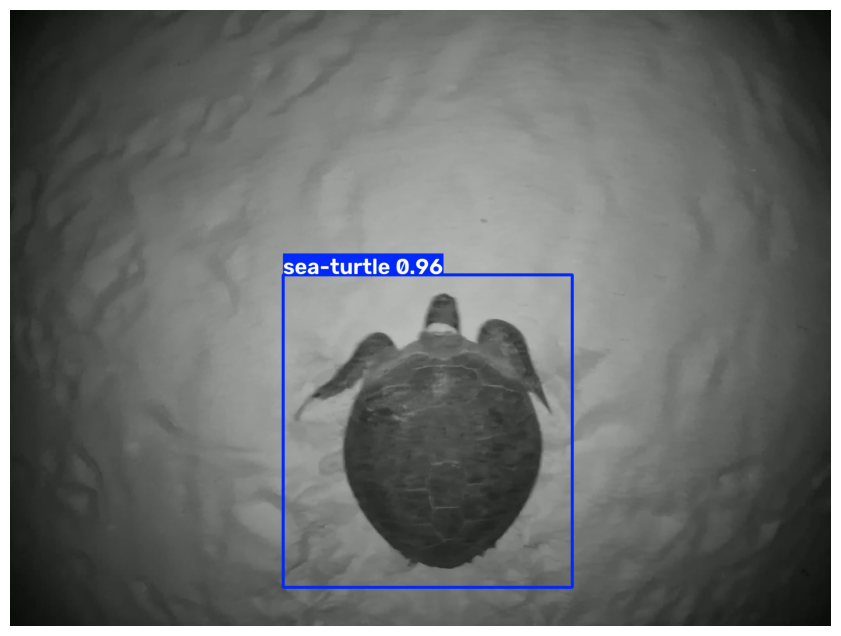

In [14]:
import matplotlib.pyplot as plt

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

## Video Inference

The trained YOLO11n model was applied to an original sea turtle video.

The model processed the video frame by frame and generated bounding boxes around detected sea turtles together with confidence scores.

This demonstrates a simple end-to-end workflow from annotated video frames to a working protected-species detection prototype.

## 4.Limitations

- Only 12 video sequences were used in this experiment.
- Consecutive frames are highly similar, so video-level splitting was used to reduce data leakage.
- The dataset contains nesting sea turtles rather than fisheries onboard footage.
- The model currently detects only one class: sea turtle.
- Performance on different camera angles, lighting conditions, and real environments has not been evaluated.

## 5.Future Work

- Use more video sequences from GTST-2023 to improve training diversity.
- Compare YOLO11n with larger YOLO models such as YOLO11s or YOLO11m.
- Extend the model from sea turtle detection to multi-class protected-species detection, such as seabirds and marine mammals.
- Add object tracking to follow the same animal across consecutive video frames.
- Evaluate the model on fisheries onboard footage or other marine environments to test its ability to generalise to new conditions.